Ahmad Yudistira ramdhany - 0110224005


  **Praktikum 13 – Machine Learning
Neural Network (Artificial Neural Network)**

1. Import Library

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

2. Menghubungkan Colab Ke Google Drive

In [92]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [93]:
path = "/content/drive/MyDrive/Machine_Learning/Praktikum13/data"

3. Load Dataset

In [94]:
df = pd.read_csv(path + "/titanic_data.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


4. Cek MIssing Value

In [95]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


5. Data Cleaning

In [96]:
# 5.1
# Hapus Kolom Yg Tidak Digunakan
# drop kolom
df = df.drop(columns=['Cabin', 'Name', 'Ticket'], axis=1)


<Axes: >

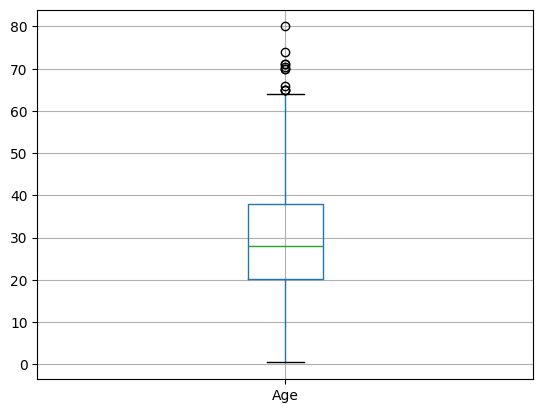

In [97]:
# 5.2
# Visualisasi Distribusi dan Outlier pada Kolom Age
df.boxplot(column=['Age'])

In [98]:
# 5.3
# Mengisi Nilai Kosong pada Kolom Age dengan Median
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipython-input-3897743981.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [99]:
# 5.4
# Mengisi Nilai Kosong pada Kolom Embarked dengan Modus
# replacing the missing value in "Embarked" column with mode value

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipython-input-2556790584.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [100]:
# 5.5
# Verifikasi Ulang Missing Values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


6. Encoding Data Kategorikal

In [101]:
replacements = {
    'Sex':{'male': 0, 'female': 1},
    'Embarked':{'S': 0, 'C': 1, 'Q': 2}
}
df.replace(replacements, inplace=True)

/tmp/ipython-input-913459230.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(replacements, inplace=True)


7. Menampilkan Dataset

In [102]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,0
3,4,1,1,1,35.0,1,0,53.1000,0
4,5,0,3,0,35.0,0,0,8.0500,0


8. Split Data dan Transformasi (Scaling)

In [103]:
# Split Data Varibel X dan Y
X = df.drop('Survived', axis=1)
y = df['Survived']

In [104]:
# Transform Data
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [105]:
# Train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

9. Modelling-Menentukan Struktur Input untuk Neural Network

In [106]:
X_train.shape

(712, 8)

In [107]:
X_train.shape[1]

8

10. Pembuatan Model Neural Network (Arsitektur ANN)


In [108]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

# Hidden Layer 1
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

# Dropout untuk mengurangi overfitting
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))

# Output Layer (binary classification)
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11. Kompilasi Model dan Ringkasan Arsitektur (Model Summary)

In [109]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

12.  Early Stopping (Pencegahan Overfitting Selama Training)

In [110]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopp = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

13. Training Model Neural Network

In [111]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopp],
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4650 - loss: 0.8420 - val_accuracy: 0.5944 - val_loss: 0.6915
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6081 - loss: 0.7152 - val_accuracy: 0.6923 - val_loss: 0.6638
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6125 - loss: 0.6801 - val_accuracy: 0.6993 - val_loss: 0.6397
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6764 - loss: 0.6512 - val_accuracy: 0.7133 - val_loss: 0.6167
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6975 - loss: 0.6125 - val_accuracy: 0.7133 - val_loss: 0.5918
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6869 - loss: 0.6082 - val_accuracy: 0.7063 - val_loss: 0.5698
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7213 - loss: 0.5765 - val_accuracy: 0.7203 - val_loss: 0.5492
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7238 - loss: 0.5846 - val_accuracy: 0.7413 - 

14. Evaluasi Model (Testing Data)

In [112]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss     :", loss)
print("Test Accuracy :", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8263 - loss: 0.4065 
Test Loss     : 0.41851627826690674
Test Accuracy : 0.8100558519363403


15. Visualisasi Hasil Pelatihan (Accuracy dan Loss)

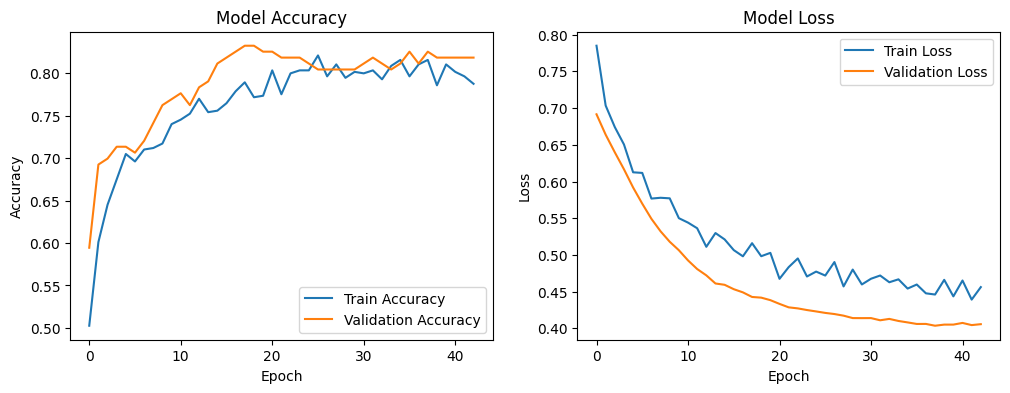

In [113]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Kesimpulan

Berdasarkan hasil praktikum Machine Learning – Neural Network (Artificial Neural Network) yang telah
dilakukan menggunakan dataset Titanic, dapat disimpulkan beberapa hal penting sebagai berikut:
1. Model Artificial Neural Network (ANN) berhasil dibangun menggunakan arsitektur berurutan
(Sequential Model) dengan dua hidden layer berukuran 32 dan 16 neuron serta fungsi aktivasi
ReLU, dan satu output layer dengan fungsi aktivasi Sigmoid untuk klasifikasi biner.
2. Model dikompilasi dengan optimizer Adam dan loss function Binary Crossentropy, serta
dievaluasi menggunakan akurasi (accuracy) sebagai metrik utama.
3. Untuk mencegah overfitting, digunakan teknik EarlyStopping dengan parameter
monitor='val_loss', patience=5, dan restore_best_weights=True, sehingga proses training
berhenti otomatis ketika performa model tidak membaik lagi.
4. Berdasarkan hasil evaluasi:


    *   Nilai Test Accuracy ≈ 0.80 (80%), menunjukkan model mampu memprediksi status keselamatan penumpang dengan cukup baik.
    *   Nilai Test Loss ≈ 0.39, menunjukkan tingkat kesalahan prediksi yang rendah.
    *   Grafik accuracy dan loss menunjukkan tren stabil tanpa tanda overfitting, dengan validation accuracy mendekati training accuracy.






